In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ngsolve import *
from ngsolve.webgui import Draw

In [2]:
import os
from pathlib import Path
import sys

sys.path.append(str(Path(os.getcwd()).parent / "src"))

import importlib
import utils
import active_gel_fem
import myosin_actin_gel_fem

importlib.reload(active_gel_fem)
importlib.reload(myosin_actin_gel_fem)
importlib.reload(utils)

from myosin_actin_gel_fem import MyosinActinGel1D, MyosinActinGel2D
from utils import tanh_source, sharp_source, animate_2d

## 2D simulation

In [11]:
T   = 25
tau = 0.05
n_samples = 120
width = 0.05
center = 0.5
interfacial_width = 0.001
Lx = 1
Ly = 1

source = tanh_source(center=center, width=width, value=1, axis='x', interface_length=interfacial_width) * \
         tanh_source(center=center, width=Ly*0.9, value=1, axis='y', interface_length=0.1)

S = 0.8*source + 0.2
m0 = source
Qsq = 2*source - 1  

param_sets = [
    [0.08, 0.4], 
    [0.2, 0.05], 
    [0.1, 1]
]

datas = [] 
for (chi0, chi1) in param_sets:
    sim2d = MyosinActinGel2D(
        width=Lx, height=Ly, maxh=0.03,
        # mechanics
        gamma = 1,
        eta_1 = 1,
        eta_2 = 0,
        chi0  = chi0,
        chi1  = chi1,
        # nematic
        kappa = 1e-4,
        beta1 = 0.2,
        beta2 = 1,
        Qsq   = Qsq,
        # density / myosin
        S     = S,
        m0    = m0,
        k0    = 0.2,
        k1    = 0.8,
        k_m   = 0.5,
        n_hill = 4,
        m_ref  = 0.1,
        D_rho = 1e-4,
        D_m   = 1e-4,
        # base
        k     = 0.5,
        D     = 1e-3,
        rho0  = 1.0,
    )

    sim2d.simulate(tend=T, tau=tau, save_interval=int(0.2/tau))
    data2d = sim2d.export(n_samples=n_samples)
    datas.append(data2d)

  4%|▎         | 18/500 [00:00<00:06, 71.90it/s]

craete bilinearformapplication


  5%|▍         | 23/500 [00:00<00:04, 108.12it/s]

craete bilinearformapplication


  4%|▍         | 22/500 [00:00<00:04, 108.72it/s]

craete bilinearformapplication


100%|██████████| 500/500 [00:04<00:00, 106.61it/s]


(125, 120, 120)
min compression: -0.26171104572653825 max compression: 0.07953230740653633
density ratio: 0.2928853761727716


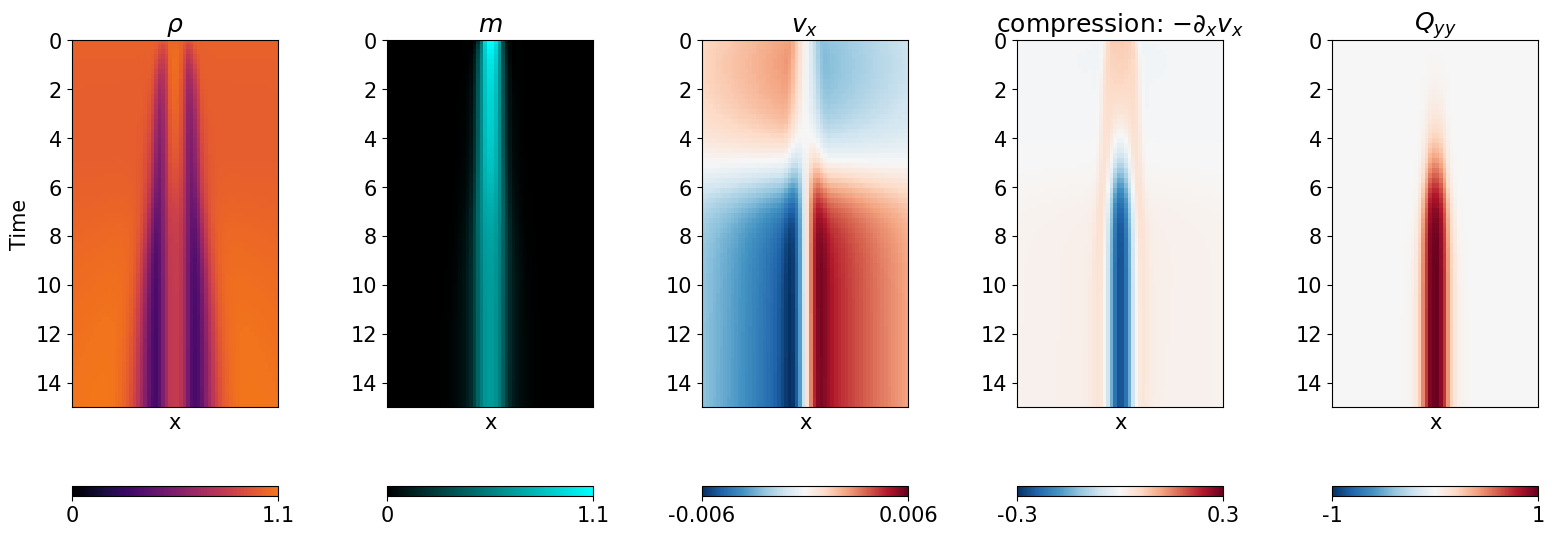

In [12]:
data2d= datas[0]  # pick the first parameter set

# Mid-line (y=0.5) profiles over time — same as 1D kymograph style
n = data2d['rho'].shape[2] // 2  # midline index
left = int((1- (100/135))*n_samples)
right = n_samples - left

compression = - np.gradient(data2d['vx'], axis=1)*n_samples 
print(compression.shape)
print('min compression:', np.min(compression), 'max compression:', np.max(compression))

print('density ratio:', np.min(data2d['rho'][-1])/data2d['rho'][-1][left, n])

import matplotlib.colors as mcolors
inferno_80 = mcolors.ListedColormap(plt.get_cmap('inferno')(np.linspace(0, 0.7, 256)))
black_cyan = mcolors.LinearSegmentedColormap.from_list("black_cyan", ["black", "cyan"])
    
plt.rcParams.update({'font.size': 15})
fig, axes = plt.subplots(1, 5, figsize=(16, 6))

t_end = 15 
fields = [
    (data2d['rho'][1:int(t_end/0.2), left:right, n], r'$\rho$',  inferno_80, dict(vmin=None, vmax=None)),
    (data2d['m'][1:int(t_end/0.2), left:right, n],   r'$m$',    black_cyan,  dict(vmin=None, vmax=None)),
    (data2d['vx'][1:int(t_end/0.2), left:right, n],  r'$v_x$',   'RdBu_r',   dict(vmin=-0.006, vmax=0.006)),
    (compression[1:int(t_end/0.2), left:right, n],   r'compression: $-\partial_x v_x$', 'RdBu_r', dict(vmin=-0.3, vmax=0.3)),
    (-data2d['Q'][1:int(t_end/0.2), left:right, n],   r'$Q_{yy}$','RdBu_r',  dict(vmin=-1, vmax=1)),
]

for ax, (field, title, cmap, kwargs) in zip(axes, fields):
    vmax = kwargs['vmax'] if kwargs['vmax'] is not None else np.max(np.abs(field))
    vmin = kwargs['vmin'] if kwargs['vmin'] is not None else (-vmax if cmap == 'RdBu_r' else 0)
    im = ax.imshow(field, aspect='auto', interpolation='none',
                   origin='upper', cmap=cmap, extent=(0, 1, t_end, 0),
                   vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, location='bottom', pad=0.15,
                 ticks=[vmin, vmax], format='%.2g')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_xticks([]) 

axes[0].set_ylabel('Time')
plt.tight_layout()
plt.savefig('../figures/wt_kymograph.svg', dpi=500, bbox_inches='tight')
plt.show()

dict_keys(['rho', 'm', 'vx', 'vy', 'comp', 'Q', 'q', 'x', 'y']) dict_keys(['rho', 'm', 'vx', 'vy', 'Q', 'q', 'x', 'y', 'comp'])


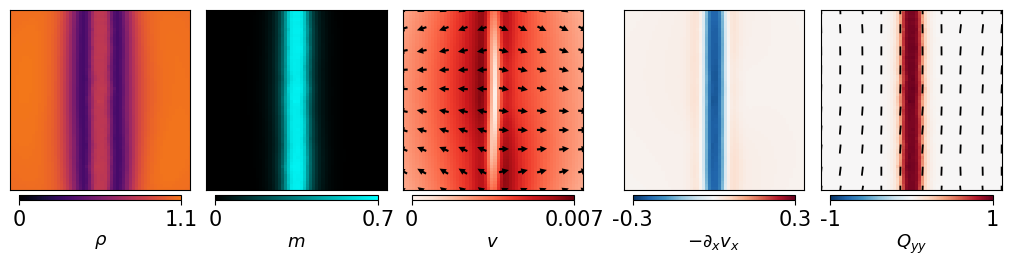

dict_keys(['rho', 'm', 'vx', 'vy', 'comp', 'Q', 'q', 'x', 'y']) dict_keys(['rho', 'm', 'vx', 'vy', 'Q', 'q', 'x', 'y', 'comp'])


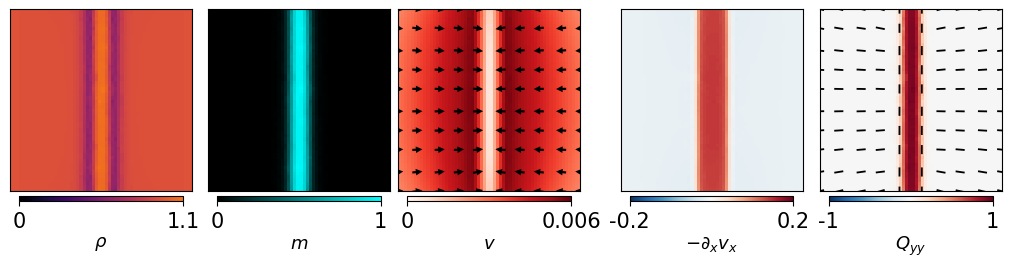

dict_keys(['rho', 'm', 'vx', 'vy', 'comp', 'Q', 'q', 'x', 'y']) dict_keys(['rho', 'm', 'vx', 'vy', 'Q', 'q', 'x', 'y', 'comp'])


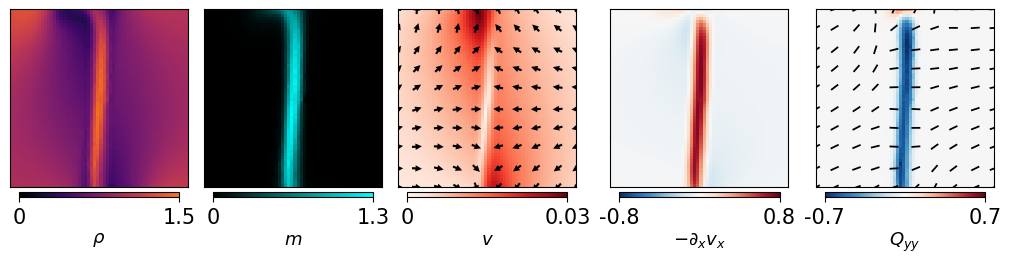

In [13]:
from utils import plot_2d_frame, animate_2d
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

import importlib
import utils
importlib.reload(utils)
from utils import plot_2d_frame

fields = [
    ('rho',  r'$\rho$',                inferno_80),
    ('m',    r'$m$',                   black_cyan),
    ('v',    r'$v$',                   'Reds'),
    ('comp', r'$-\partial_x v_x$',     'RdBu_r'),
    ('Q',    r'$Q_{yy}$',             'RdBu_r'),
]

for ((chi0, chi1), data2d) in zip(param_sets, datas):
    dx = data2d['x'][1] - data2d['x'][0]
    data2d['comp'] = -np.gradient(data2d['vx'], dx, axis=1)
    keys = ['rho', 'm', 'vx', 'vy', 'comp', 'Q', 'q']
    cropped_data = {key: data2d[key][:, left:right, left:right] for key in keys}
    cropped_data['x'] = data2d['x'][left:right]
    cropped_data['y'] = data2d['y'][left:right]

    print(cropped_data.keys(), data2d.keys())
    plot_2d_frame(cropped_data, t=-1, fields=fields, title=f'', filename=f'../figures/2d_snapshot_chi0_{chi0}_chi1_{chi1}.svg', n_arrows=10)

In [14]:
# Save animation as MP4
save_interval = int(0.5 / tau)  # frames saved every 0.5 time units
animate_2d(data2d, filename=f'../figures/actin_myo_2d_chi0_{sim2d.chi0}_chi1_{sim2d.chi1}.mp4',
           n_arrows=10, fps=6, dt=0.5, 
           title_fmt='t = {t:.1f}', cmap_rho=inferno_80)

Saved ../figures/actin_myo_2d_chi0_0.1_chi1_1.mp4  (125 frames, 6 fps)
